# Satellite Launch Trends – Payload to Orbit
**UCS Satellite Database Analysis (May 2023 version)**

This notebook provides an overview of:
- Annual number of satellites launched
- Total payload mass launched per year (million kg)
- Breakdown by orbit class (LEO, GEO, MEO, Elliptical)
- Comparison of original vs imputed mass trends

Data source: Union of Concerned Scientists (UCS) Satellite Database (~7,560 entries)

Last major update: May 2023

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [9]:
# 1. Load data, basic cleaning

print("Loading UCS Satellite Database...")

df = pd.read_excel("UCS_Satellite_Database.xlsx")  # ← change path if needed

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Rename messy columns for easier use
df = df.rename(columns={
    'Class of Orbit': 'orbit_class',
    'Type of Orbit': 'orbit_type',
    'Launch Mass (kg.)': 'launch_mass_kg',
    'Date of Launch': 'launch_date',
    'Country of Operator/Owner': 'operator_country',
    'Purpose': 'purpose',
    'Longitude of GEO (degrees)': 'geo_longitude',
    'Perigee (km)': 'perigee_km',
    'Apogee (km)': 'apogee_km',
    'Inclination (degrees)': 'inclination_deg',
    'Period (minutes)': 'period_min',
    'Eccentricity': 'eccentricity'
})

# Extract year
df['year'] = pd.to_datetime(df['launch_date'], errors='coerce').dt.year

# Convert mass to numeric
df['launch_mass_kg'] = pd.to_numeric(df['launch_mass_kg'], errors='coerce')

# Drop completely empty placeholder columns
drop_cols = [col for col in df.columns if col.startswith('Unnamed:')]
df = df.drop(columns=drop_cols)

Loading UCS Satellite Database...
Shape: (7560, 68)
Columns: ['Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)', 'Period (minutes)', 'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle', 'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28', 'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2', 'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 

In [10]:
# Handle missing launch mass (simple median by orbit class)

print("\nMissing launch mass before imputation:", df['launch_mass_kg'].isna().sum())

orbit_medians = df.groupby('orbit_class')['launch_mass_kg'].median()
global_median = df['launch_mass_kg'].median()

df['launch_mass_imputed'] = df['launch_mass_kg'].fillna(
    df['orbit_class'].map(orbit_medians)
).fillna(global_median)

print("Missing after imputation:", df['launch_mass_imputed'].isna().sum())


Missing launch mass before imputation: 245
Missing after imputation: 0


In [11]:
# More cleaning: focus on rows with year and orbit class
# Keep rows with year and orbit class

df_clean = df.dropna(subset=['year', 'orbit_class']).copy()

print(f"Analysis-ready rows: {len(df_clean):,} / {len(df):,} "
      f"({len(df_clean)/len(df):.1%})")

Analysis-ready rows: 7,557 / 7,560 (100.0%)


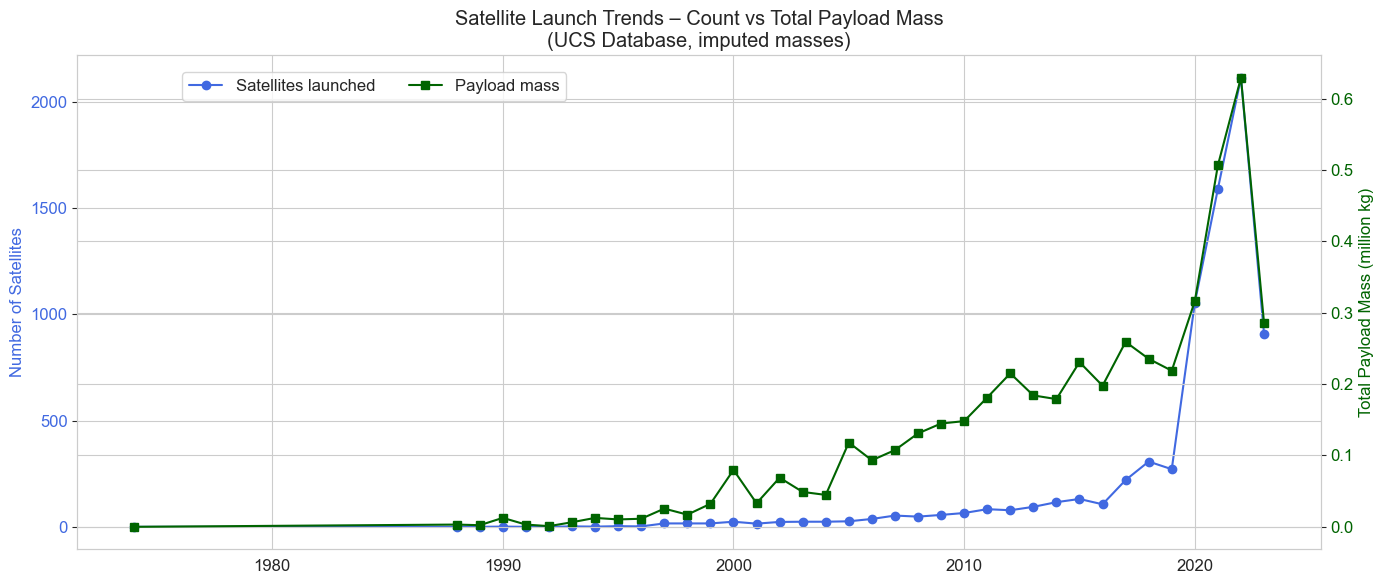

In [12]:
# Visualizations 

# Satellites launched & total mass per year (dual axis)
# Note: mass is imputed, so interpret with caution. Still useful for trend analysis.

annual_launches = df_clean.groupby('year').size()
annual_mass     = df_clean.groupby('year')['launch_mass_imputed'].sum() / 1_000_000

fig, ax1 = plt.subplots()
ax1.plot(annual_launches.index, annual_launches, color='royalblue', marker='o', label='Satellites launched')
ax1.set_ylabel('Number of Satellites', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')

ax2 = ax1.twinx()
ax2.plot(annual_mass.index, annual_mass, color='darkgreen', marker='s', label='Payload mass')
ax2.set_ylabel('Total Payload Mass (million kg)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

plt.title('Satellite Launch Trends – Count vs Total Payload Mass\n(UCS Database, imputed masses)')
fig.legend(loc='upper left', bbox_to_anchor=(0.13, 0.88), ncol=2)
plt.xlabel('Year')
plt.tight_layout()
plt.show()

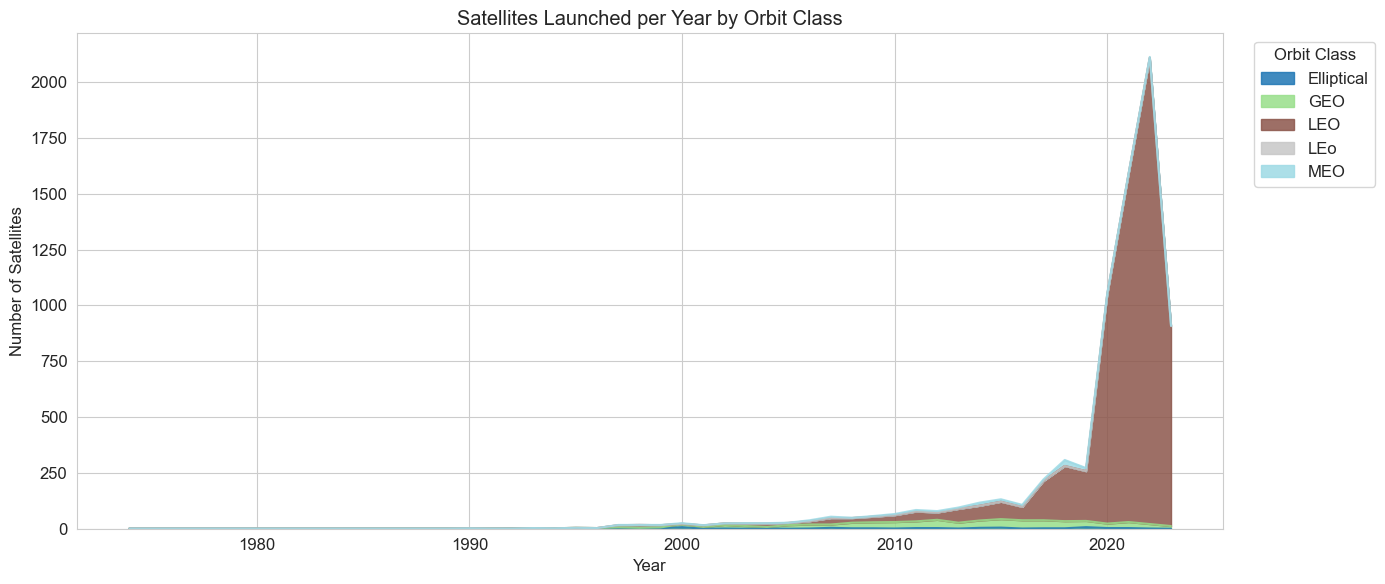

In [13]:
# Breakdown by orbit class (stacked area plot)
annual_by_orbit = df_clean.groupby(['year', 'orbit_class']).size().unstack(fill_value=0)

annual_by_orbit.plot(kind='area', stacked=True, colormap='tab20', alpha=0.85)
plt.title('Satellites Launched per Year by Orbit Class')
plt.ylabel('Number of Satellites')
plt.xlabel('Year')
plt.legend(title='Orbit Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
# Summary stats
print("\nTop 10 operator countries by satellite count:")
print(df_clean['operator_country'].value_counts().head(10))

print("\nMedian launch mass by orbit class:")
print(df_clean.groupby('orbit_class')['launch_mass_imputed'].median().sort_values(ascending=False))


Top 10 operator countries by satellite count:
operator_country
USA               5163
United Kingdom     651
China              616
Russia             181
Japan               87
ESA                 63
Multinational       63
Canada              60
India               59
Luxembourg          57
Name: count, dtype: int64

Median launch mass by orbit class:
orbit_class
GEO           4190.5
Elliptical    1280.0
MEO            800.0
LEO            260.0
LEo             42.0
Name: launch_mass_imputed, dtype: float64
